<a href="https://colab.research.google.com/github/chidimo/AI-MSc-Assessment/blob/main/mldm/task-3-sentiment-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
from wordcloud import WordCloud
import nltk
import nltk

nltk.download(['stopwords', 'punkt', 'wordnet', 'omw-1.4', 'vader_lexicon'])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chidimo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/chidimo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/chidimo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/chidimo/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/chidimo/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
stop_words = nltk.corpus.stopwords.words("english")
stemmer = nltk.stem.PorterStemmer()
lemmatizer = nltk.stem.WordNetLemmatizer()


def preprocess_text(text):
    tokenized_document = nltk.tokenize.RegexpTokenizer("[a-zA-Z0-9']+").tokenize(text)
    cleaned_tokens = [
        word.lower() for word in tokenized_document if word.lower() not in stop_words
    ]
    stemmed_text = [stemmer.stem(word) for word in cleaned_tokens]
    return stemmed_text

## SMS Spam collection

In [3]:
data = pd.read_csv('data/SMSSpamCollection.txt', sep='\t', header=None)
data.columns = ['Target_Label', 'Text']
data.head()

,Target_Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print('\n All Data Labels')
print(data.groupby('Target_Label').count())


 All Data Labels
              Text
Target_Label      
ham           4825
spam           747


In [5]:
data['Text'] = data['Text'].apply(preprocess_text)
data.head()

,Target_Label,Text
0,ham,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,"[ok, lar, joke, wif, u, oni]"
2,spam,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"[nah, think, goe, usf, live, around, though]"


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['Text'].map(''.join))
X = pd.DataFrame(X.toarray())
X.head()

,0,1,2,3,4,5,6,7,8,9,...,5492,5493,5494,5495,5496,5497,5498,5499,5500,5501
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.model_selection import train_test_split

y = data['Target_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=99)

<Axes: xlabel='Target_Label', ylabel='count'>

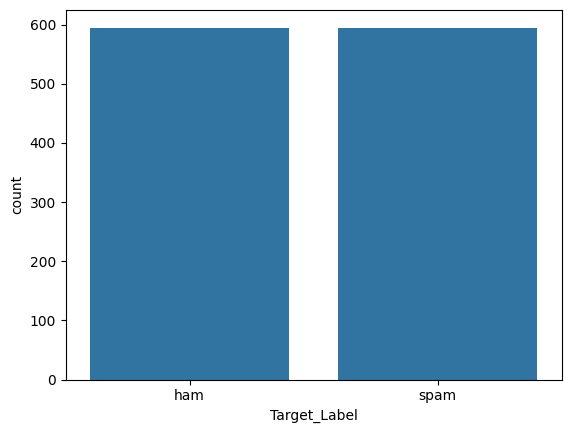

In [8]:
from imblearn.under_sampling import RandomUnderSampler

resampler = RandomUnderSampler(random_state=0)
X_train_undersampled, y_train_undersampled = resampler.fit_resample(X_train, y_train)

sns.countplot(x=y_train_undersampled)


In [9]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_undersampled, y_train_undersampled)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [10]:
y_pred = model.predict(X_test)
y_pred

array(['spam', 'spam', 'spam', ..., 'ham', 'spam', 'spam'],
      shape=(1115,), dtype='<U4')

In [11]:
from sklearn import metrics

acc = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}.2f\n\n")
cm = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(cm)
print('-----'*10)
result = metrics.classification_report(y_test, y_pred)
print('Classification Report')
print(result)

Accuracy: 0.18026905829596412.2f


Confusion Matrix
[[ 49 914]
 [  0 152]]
--------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         ham       1.00      0.05      0.10       963
        spam       0.14      1.00      0.25       152

    accuracy                           0.18      1115
   macro avg       0.57      0.53      0.17      1115
weighted avg       0.88      0.18      0.12      1115



# Amazon reviews analyzer


In [12]:
reviews = pd.read_csv("data/Reviews_of_Amazon_Products.csv")
reviews.head()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username
0,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-09-03T00:00:00.000Z,I thought it would be as big as small paper bu...,Too small,llyyue
1,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-06-06T00:00:00.000Z,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi
2,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-20T00:00:00.000Z,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo
3,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-11-02T17:33:31.000Z,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry
4,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-24T00:00:00.000Z,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack


In [13]:
reviews.describe()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username
count,1123,1123,1123,1123,1123,1123,1123,1123
unique,2,7,1,2,237,1048,820,983
top,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2017-01-23T00:00:00.000Z,I am really enjoying my new kindle fire hd 8. ...,Great tablet,Mike
freq,1016,797,1123,1112,48,3,56,5


In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sentiment = SentimentIntensityAnalyzer()

print(sentiment.polarity_scores("This movie is great"))
print(sentiment.polarity_scores("This movie is not great"))

{'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6249}
{'neg': 0.452, 'neu': 0.548, 'pos': 0.0, 'compound': -0.5096}


In [15]:
# Compute all sentiment scores in one pass
sentiment_scores = reviews["reviews.text"].apply(
    lambda review: pd.Series(sentiment.polarity_scores(review))
)
sentiment_scores

,neg,neu,pos,compound
0,0.081,0.709,0.210,0.7329
1,0.000,0.744,0.256,0.5826
2,0.085,0.772,0.143,0.3612
3,0.000,0.843,0.157,0.9727
4,0.000,0.661,0.339,0.9072
...,...,...,...,...
1118,0.201,0.514,0.285,0.4215
1119,0.084,0.807,0.109,0.1779
1120,0.000,0.889,0.111,0.6103
1121,0.000,0.812,0.188,0.7577


In [16]:
# Assign all columns at once
reviews[["neg", "neu", "pos", "compound"]] = sentiment_scores
reviews.head()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username,neg,neu,pos,compound
0,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-09-03T00:00:00.000Z,I thought it would be as big as small paper bu...,Too small,llyyue,0.081,0.709,0.210,0.7329
1,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-06-06T00:00:00.000Z,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,0.000,0.744,0.256,0.5826
2,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-20T00:00:00.000Z,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,0.085,0.772,0.143,0.3612
3,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-11-02T17:33:31.000Z,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,0.000,0.843,0.157,0.9727
4,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-24T00:00:00.000Z,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,0.000,0.661,0.339,0.9072


In [17]:
reviews[["compound", "neg", "neu", "pos"]].describe()

,compound,neg,neu,pos
count,1123.000000,1123.000000,1123.000000,1123.000000
mean,0.623324,0.033545,0.694907,0.271563
std,0.347236,0.058432,0.147549,0.152466
min,-0.867400,0.000000,0.230000,0.000000
25%,0.493900,0.000000,0.592000,0.163000
50%,0.750600,0.000000,0.705000,0.259000
75%,0.865800,0.055500,0.800500,0.380000
max,0.999200,0.475000,1.000000,0.689000


<Axes: xlabel='compound', ylabel='Count'>

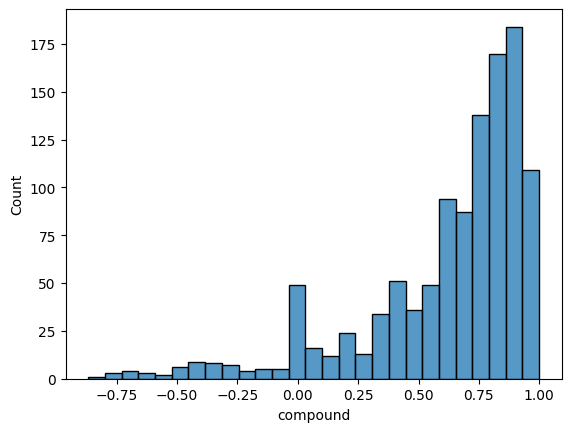

In [18]:
sns.histplot(reviews["compound"])

<Axes: xlabel='pos', ylabel='Count'>

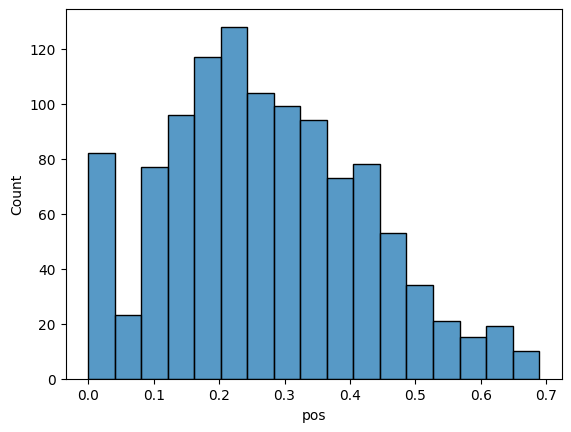

In [19]:
sns.histplot(reviews["pos"])

<Axes: xlabel='neg', ylabel='Count'>

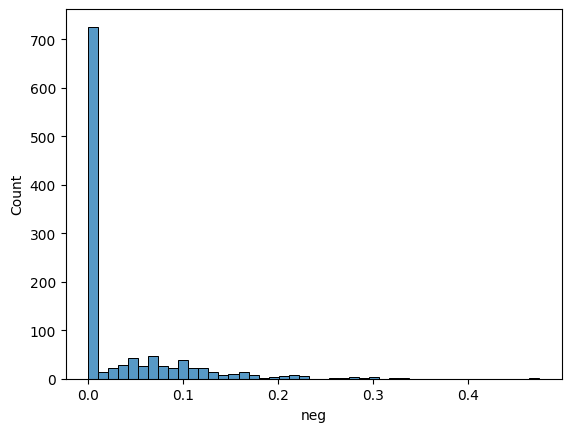

In [20]:
sns.histplot(reviews["neg"])

In [21]:
(reviews["compound"] <= 0).groupby(reviews["name"]).sum()

name
Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)                                         12
Fire HD 8 Tablet,  Wi-Fi, 16 GB-Magenta                                                       67
Fire HD 8 Tablet,  Wi-Fi, 32 GB-Black                                                          5
Fire HD 8 Tablet,  Wi-Fi, 32 GB-Magenta                                                        5
Fire HD 8 Tablet, Wi-Fi, 16 GB-Blue                                                            1
Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue                                                           10
Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers     1
Name: compound, dtype: int64

In [22]:
negative_column = "% negative reviews"

percent_negative = pd.DataFrame(
    (reviews["compound"] <= 0).groupby(reviews["name"]).sum()
    / reviews["name"].groupby(reviews["name"]).count()
    * 100,
    columns=[negative_column],
).sort_values(by=negative_column)

percent_negative

,% negative reviews
name,
"Fire HD 8 Tablet, Wi-Fi, 16 GB-Blue",1.960784
"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",8.406524
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Black",8.620690
"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",9.090909
"Amazon Kindle E-Reader 6"" Wifi (8th Generation, 2016)",12.500000
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Magenta",12.500000
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue",14.285714


<Axes: xlabel='% negative reviews', ylabel='name'>

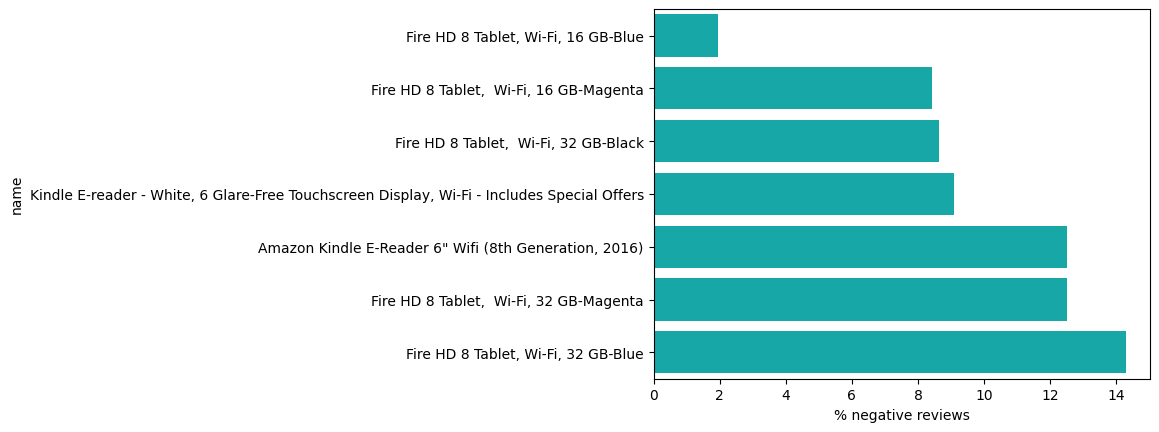

In [23]:
sns.barplot(
    data=percent_negative, x=negative_column, y=percent_negative.index, color="c"
)

In [24]:
tablet_name = "Fire HD 8 Tablet,  Wi-Fi, 16 GB-Magenta"

reviews["processed_review"] = reviews["reviews.text"].apply(preprocess_text)

reviews_positive_subset = reviews.loc[
    (reviews["name"] == tablet_name) & (reviews["compound"] > 0), :
]
reviews_negative_subset = reviews.loc[
    (reviews["name"] == tablet_name) & (reviews["compound"] <= 0), :
]

reviews_positive_subset.head()  # , reviews_negative_subset.head()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username,neg,neu,pos,compound,processed_review
228,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2017-03-18T00:00:00.000Z,This was bought to replace my old Kindle with ...,Great picture quality,Janet,0.0,0.901,0.099,0.6476,"[bought, replac, old, kindl, keypad, experimen..."
229,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2016-12-23T00:00:00.000Z,outstanding replacement tablet for my outdated...,kindle fire hd8 2016,wallymich,0.0,0.667,0.333,0.6124,"[outstand, replac, tablet, outdat, overpr, ipa..."
230,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2017-01-28T00:00:00.000Z,This is a great tablet for the price. I have o...,Great tablet,Linda,0.0,0.868,0.132,0.6249,"[great, tablet, price, one, purchas, year, ago..."
231,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2016-12-24T00:00:00.000Z,"She hasn't used the it yet, but my son did a q...",Christmas gift for my daughter,flex3117,0.0,0.879,0.121,0.2960,"[use, yet, son, quick, check, seem, fine]"
232,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2017-04-13T00:00:00.000Z,I have had a few kindle's in the past so this ...,In love!,Steph05,0.0,0.767,0.233,0.9769,"[kindle', past, noth, new, love, one, screen, ..."


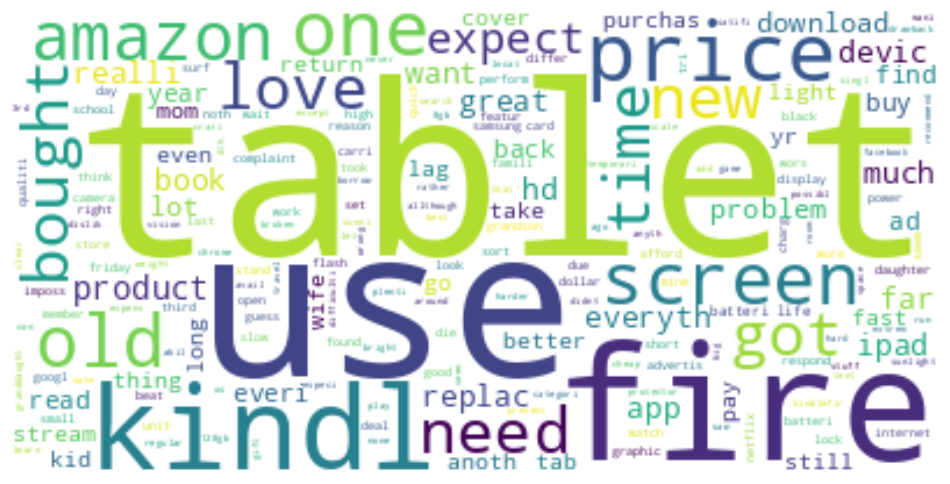

In [25]:
neg_tokens = [
    word for review in reviews_negative_subset["processed_review"] for word in review
]
wordcloud = WordCloud(background_color="white").generate_from_text(" ".join(neg_tokens))

plt.figure(figsize=(12, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

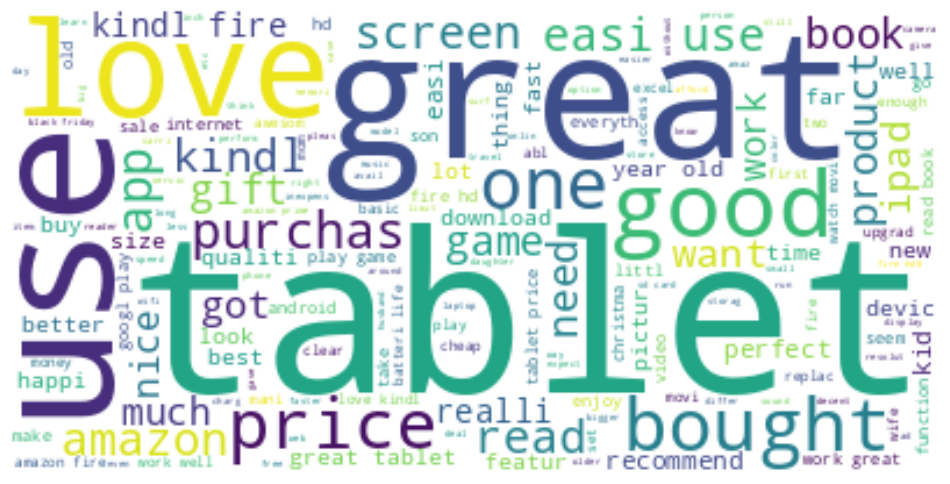

In [26]:
pos_tokens = [
    word for review in reviews_positive_subset["processed_review"] for word in review
]
wordcloud = WordCloud(background_color="white").generate_from_text(" ".join(pos_tokens))

plt.figure(figsize=(12, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

tablet  great    use   love   good   easi  price  kindl   fire amazon 
   407    285    270    202    144    139    138    132    126    124 


<Axes: xlabel='Samples', ylabel='Counts'>

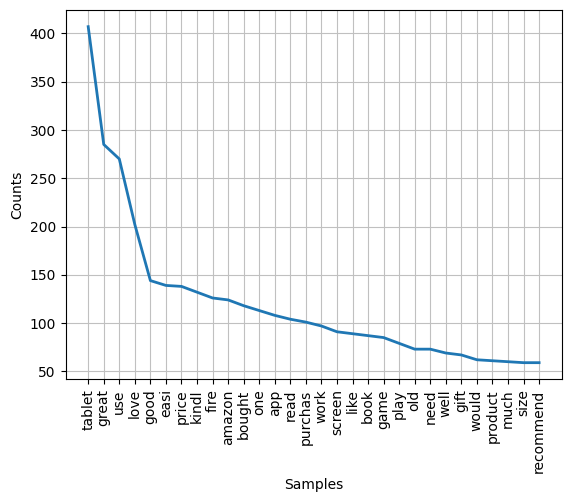

In [27]:
from nltk.probability import FreqDist

pos_freqdist = FreqDist(pos_tokens)
pos_freqdist.tabulate(10)
pos_freqdist.plot(30)

tablet    use   fire  kindl  price    one    old screen amazon bought 
    25     19     17     12     12     10      9      9      8      7 


<Axes: xlabel='Samples', ylabel='Counts'>

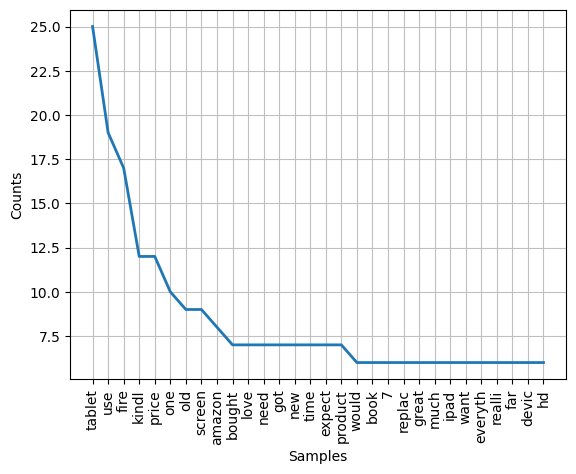

In [28]:
from nltk.probability import FreqDist

neg_freqdist = FreqDist(neg_tokens)
neg_freqdist.tabulate(10)
neg_freqdist.plot(30)